<a href="https://colab.research.google.com/github/VI-KA-trs/compling/blob/main/%D0%91%D0%B0%D1%80%D0%B8%D0%BD%D0%BE%D0%B2%D0%B0_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **RNN/LSTM**

Цель семинара: получить практический опыт работы с RNN (LSTM) в PyTorch на задачах генерации последовательностей

Мы разберем полный пайплайн разработки от препроцессинга данных до обучения и экспериментов с гиперпараметрами

Кстати, что мы называем **пайплайном**?

В Google Colab (рекомендуется активировать GPU: `Среда выполнения → Сменить среду выполнения → T4 GPU`)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import reuters

### **ЧАСТЬ 1: ДЕМО**
*   **Задача модели:** предсказание случайного временного ряда (синусоида)
*   **Цель демонстрации:** показать полный и минимальный рабочий пайплайн RNN на задаче, связанной с обработкой данных, передающих изменения во времени
*   **План:**
    1.  Подготовка последовательностей (sequences)
    2.  Архитектура `nn.LSTM`
    3.  Обучение модели
    4.  Получение метрик оценки
    5.  Визуализация и интерпретация результата

### 1. ГЕНЕРАЦИЯ И ПОДГОТОВКА ДАННЫХ

In [ ]:
def generate_sine_wave(seq_length=1000, periods=5):
    """Генерация синусоиды."""
    x = np.linspace(0, periods * 2 * np.pi, seq_length)
    y = np.sin(x)
    return y

# Генерация данных
data = generate_sine_wave()
print(f"Длина временного ряда: {len(data)}")

Длина временного ряда: 1000


In [ ]:
# Параметры последовательностей
SEQ_LEN = 50  # Длина входной последовательности для предсказания
BATCH_SIZE = 16

In [ ]:
def create_sequences(data, seq_len):
    """Создание пар (входная последовательность, целевое значение)."""
    sequences = []
    targets = []
    for i in range(len(data) - seq_len - 1):
        seq = data[i:i + seq_len]
        target = data[i + seq_len]
        sequences.append(seq)
        targets.append(target)
    return np.array(sequences), np.array(targets)

In [ ]:
# Создание последовательностей
X, y = create_sequences(data, SEQ_LEN)
print(f"Форма X (последовательности): {X.shape}")
print(f"Форма y (цели): {y.shape}")

Форма X (последовательности): (949, 50)
Форма y (цели): (949,)


In [ ]:
# Преобразование в тензоры PyTorch и добавление размерности для признаков
X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # [примеры, SEQ_LEN, 1]
y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # [примеры, 1]
print(f"Форма X (тензор): {X.shape}")
print(f"Форма y (тензор): {y.shape}")

Форма X (тензор): torch.Size([949, 50, 1])
Форма y (тензор): torch.Size([949, 1])


In [ ]:
# Разделение на обучающую и тестовую выборки
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [ ]:
### 2. ОПРЕДЕЛЕНИЕ МОДЕЛИ LSTM
class SineLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True  # формат [batch, seq_len, features]
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Инициализация скрытого состояния и состояния ячейки
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        # Прямой проход через LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Берем только последний выход последовательности для предсказания
        out = self.fc(out[:, -1, :])
        return out

In [ ]:
# Инициализация модели
model = SineLSTM()
print(f"Модель:\n{model}")

Модель:
SineLSTM(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


### 3. ОБУЧЕНИЕ МОДЕЛИ

In [ ]:
# Гиперпараметры
EPOCHS = 20
LEARNING_RATE = 0.01

# Функция потерь и оптимизатор
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Тренировочный цикл
train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    model.train()

    # Прямой проход
    predictions = model(X_train)
    loss = criterion(predictions, y_train)

    # Обратное распространение
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Оценка на тестовой выборке
    model.eval()
    with torch.no_grad():
        test_predictions = model(X_test)
        test_loss = criterion(test_predictions, y_test)
        test_losses.append(test_loss.item())

    if (epoch + 1) % 5 == 0:
        print(f'Эпоха [{epoch+1}/{EPOCHS}], '
              f'Ошибка обучения: {loss.item():.6f}, '
              f'Ошибка теста: {test_loss.item():.6f}')

Эпоха [5/20], Ошибка обучения: 0.474357, Ошибка теста: 0.088352
Эпоха [10/20], Ошибка обучения: 0.141702, Ошибка теста: 0.128243
Эпоха [15/20], Ошибка обучения: 0.032086, Ошибка теста: 0.028653
Эпоха [20/20], Ошибка обучения: 0.042564, Ошибка теста: 0.022978


### 4. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ

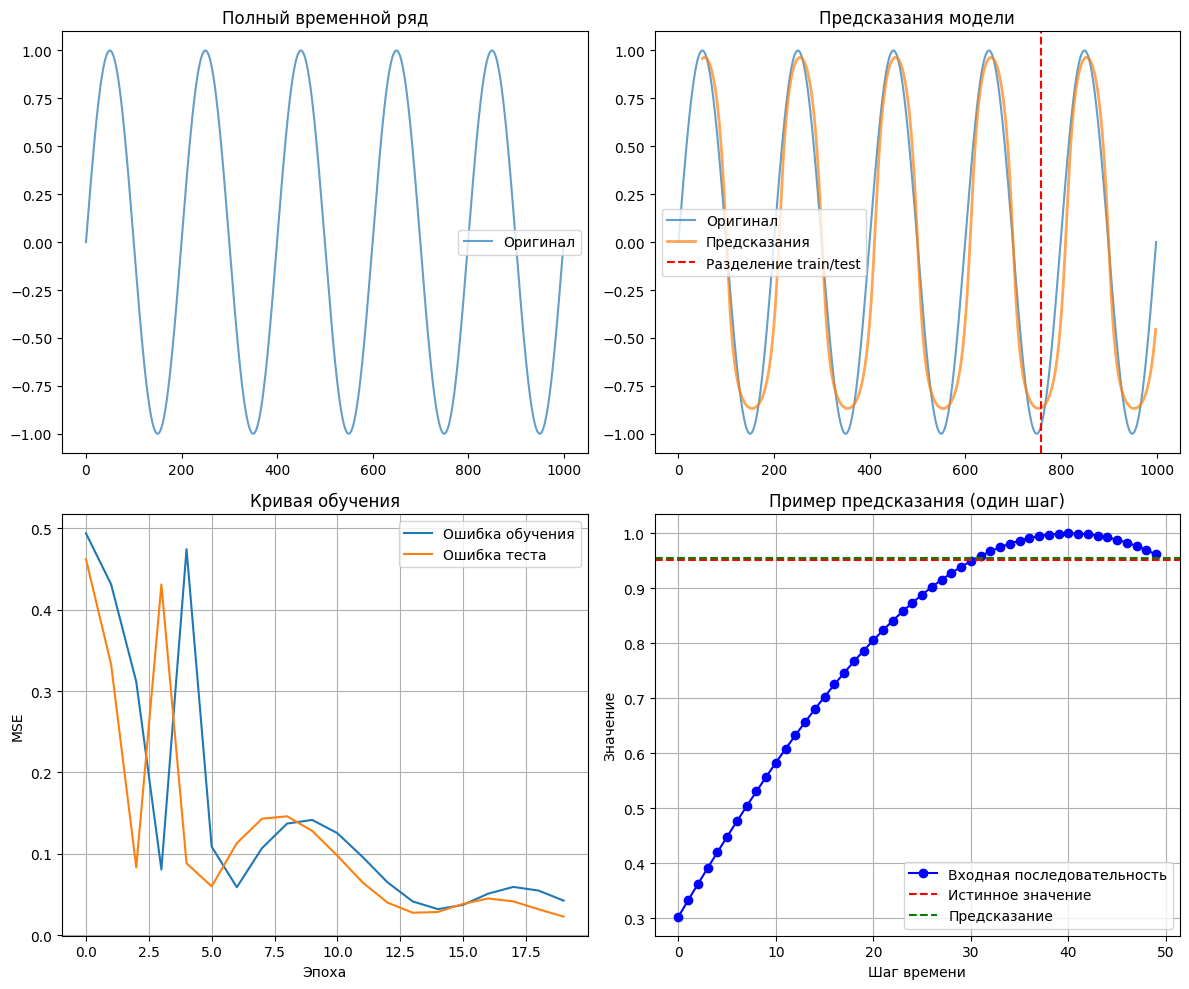

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# График 1: Оригинальные данные и предсказания
axes[0, 0].plot(data, label='Оригинал', alpha=0.7)
axes[0, 0].set_title('Полный временной ряд')
axes[0, 0].legend()

# График 2: Предсказания на тестовой выборке
model.eval()
with torch.no_grad():
    all_predictions = model(X).numpy()

# Создание массива для отображения предсказаний
pred_series = np.full_like(data, np.nan)
pred_series[SEQ_LEN:SEQ_LEN + len(all_predictions)] = all_predictions.squeeze()

axes[0, 1].plot(data, label='Оригинал', alpha=0.7)
axes[0, 1].plot(pred_series, label='Предсказания', alpha=0.7, linewidth=2)
axes[0, 1].axvline(x=split_idx, color='r', linestyle='--', label='Разделение train/test')
axes[0, 1].set_title('Предсказания модели')
axes[0, 1].legend()

# График 3: Ошибки обучения и теста
axes[1, 0].plot(train_losses, label='Ошибка обучения')
axes[1, 0].plot(test_losses, label='Ошибка теста')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('MSE')
axes[1, 0].set_title('Кривая обучения')
axes[1, 0].legend()
axes[1, 0].grid(True)

# График 4: Пример одного предсказания
sample_idx = split_idx + 50
axes[1, 1].plot(range(SEQ_LEN), X[sample_idx].squeeze().numpy(),
                'bo-', label='Входная последовательность')
axes[1, 1].axhline(y=y[sample_idx].item(), color='r', linestyle='--',
                   label='Истинное значение')
axes[1, 1].axhline(y=all_predictions[sample_idx].item(), color='g',
                   linestyle='--', label='Предсказание')
axes[1, 1].set_xlabel('Шаг времени')
axes[1, 1].set_ylabel('Значение')
axes[1, 1].set_title('Пример предсказания (один шаг)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

### 5. ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ
1. Кривая обучения должна снижаться на обеих выборках
2. Предсказания должны следовать за оригинальным рядом
3. Разрыв между train/test loss указывает на переобучение
4. Модель учится предсказывать следующий шаг синусоиды

Take aways:

1. Подготовка последовательностей: как из временного ряда создаются пары (окно истории -> целевое значение)?

2. Архитектура LSTM: batch_first=True, почему берем out[:, -1, :]

3. Цикл обучения: разделение на model.train() и model.eval(), логика .zero_grad(), .backward(), .step()

4. Визуализация: как интерпретировать каждый из 4-х графиков?

---

# ПРАКТИКА

1. ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНЫЙ ПРОСМОТР ДАННЫХ

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import reuters

# TODO 1.1: Загрузите датасет Reuters
(x_train, y_train), (x_test, y_test) = reuters.load_data()

# TODO 1.2: Изучите структуру данных
print("Тип x_train:", type(x_train))
print("Длина x_train:", len(x_train))
print("Первая последовательность (первые 10 индексов):", x_train[0][:10])
print("Длина первой последовательности:", len(x_train[0]))

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Тип x_train: <class 'numpy.ndarray'>
Длина x_train: 8982
Первая последовательность (первые 10 индексов): [1, 27595, 28842, 8, 43, 10, 447, 5, 25, 207]
Длина первой последовательности: 87


2. ПОДГОТОВКА СЛОВАРЯ И ДЕКОДИРОВАНИЕ

In [ ]:
# TODO 2.1: Загрузите словарь слов
word_index = reuters.get_word_index()
reverse_word_index = {value: key for (key, value) in word_index.items()}

# TODO 2.2: Реализуйте функцию декодирования последовательности
def decode_sequence(sequence):
    return ' '.join([reverse_word_index.get(i-3, '?') for i in sequence])

first_article = decode_sequence(x_train[0])
print("\nПервая статья (первые 200 символов):", first_article[:200])

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Первая статья (первые 200 символов): ? mcgrath rentcorp said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net shou


3. ПОДГОТОВКА ДАННЫХ ДЛЯ ГЕНЕРАЦИИ ТЕКСТА

In [ ]:
# TODO 3.1: Объедините первые 1000 статей в один текст
max_articles = 1000
max_articles_idx = x_train[:max_articles]
max_articles_texts = [decode_sequence(seq) for seq in max_articles_idx]
texts = ' '.join(max_articles_texts)

print(f"Общая длина текста (символов): {len(texts)}")
print("Пример текста:", texts[:500])

Общая длина текста (символов): 815340
Пример текста: ? mcgrath rentcorp said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3 ? generale de banque sa lt genb br and lt heller overseas corp of chicago have each taken 50 pct 


In [ ]:

# TODO 3.2: Создайте словари для преобразования символов в индексы и обратно
chars = sorted(list(set(texts)))
print(chars)
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

vocab_size = len(chars)
print(f"Размер словаря (уникальных символов): {vocab_size}")

# TODO 3.3: Преобразуйте текст в последовательность индексов
text_as_int = [char_to_idx[ch] for ch in texts]
texts[:10], text_as_int[:10]

[' ', "'", '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Размер словаря (уникальных символов): 39


('? mcgrath ', [12, 0, 25, 15, 19, 30, 13, 32, 20, 0])

4. ФОРМИРОВАНИЕ ПРОМПТОВ И ОТВЕТОВ

In [ ]:
seq_length = 100

# TODO 4.1: Реализуйте функцию create_sequences для создания обучающих примеров
def create_sequences(text_indices, seq_len):
    input_seq = []
    target_seq = []

    for i in range(len(text_indices)-seq_len):
        current_x_seq = text_indices[i:i+seq_len]
        input_seq.append(current_x_seq)

        current_y_seq = text_indices[i+seq_len]
        target_seq.append(current_y_seq)

    return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target_seq, dtype=torch.long)

input_seq, target_seq = create_sequences(text_as_int, seq_length)

print(f"\nКоличество примеров: {len(input_seq)}")
print(f"Форма input_seq: {input_seq.shape}")
print(f"Форма target_seq: {target_seq.shape}")

# TODO 4.2: Создайте DataLoader для пакетной обработки
batch_size = 32
dataset = torch.utils.data.TensorDataset(input_seq, target_seq)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)


Количество примеров: 815240
Форма input_seq: torch.Size([815240, 100])
Форма target_seq: torch.Size([815240])


5. ОПРЕДЕЛЕНИЕ МОДЕЛИ LSTM

In [ ]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, num_layers=2, embedding_dim=64):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # TODO 5.1: Определите слои модели
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2,
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        # TODO 5.2: Реализуйте forward pass
        # Шаг 1: Примените слой эмбеддинга
        embedded = self.embedding(x)

        # Шаг 2: Прямой проход через LSTM
        if hidden is None:
            lstm_out, hidden = self.lstm(embedded)
        else:
            lstm_out, hidden = self.lstm(embedded, hidden)

        # Шаг 3: Возьмите только последний выход LSTM
        lstm_out = lstm_out[:, -1, :]

        # Шаг 4: Примените полносвязный слой
        output = self.fc(lstm_out)

        return output, hidden

device = torch.device('cuda')

# TODO 5.3: Инициализируйте модель
model = CharLSTM(vocab_size=vocab_size, hidden_size=128, num_layers=2)
model = model.to(device)
print(f"\nМодель:\n{model}")


Модель:
CharLSTM(
  (embedding): Embedding(39, 64)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=39, bias=True)
)


6. ОБУЧЕНИЕ МОДЕЛИ

In [ ]:
EPOCHS = 4
LEARNING_RATE = 0.005

# TODO 6.1: Определите функцию потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# TODO 6.2: Реализуйте функцию генерации текста
def generate_text(model, seed_text, length=100, temperature=1.0):
    """Генерация текста на основе начальной последовательности."""
    model.eval()
    generated = seed_text

    # Преобразуем seed в индексы, фильтруя символы, которых нет в словаре
    seed_indices = []
    for ch in seed_text:
        if ch in char_to_idx:
            seed_indices.append(char_to_idx[ch])
        else:
            # Если символа нет в словаре, используем первый попавшийся символ
            seed_indices.append(0)

    if len(seed_indices) == 0:
        seed_indices = [0]  # На случай пустого seed

    with torch.no_grad():
        # Создаем начальное hidden state
        batch_size = 1

        h0 = torch.zeros(model.num_layers, batch_size, model.hidden_size).to(device)
        c0 = torch.zeros(model.num_layers, batch_size, model.hidden_size).to(device)
        hidden = (h0, c0)

        # "Прогреваем" модель на seed последовательности
        for i in range(len(seed_indices) - 1):
            input_tensor = torch.tensor([[seed_indices[i]]], dtype=torch.long).to(device)
            _, hidden = model(input_tensor, hidden)

        # Начинаем генерацию
        current_input = torch.tensor([[seed_indices[-1]]], dtype=torch.long).to(device)

        for _ in range(length):
            output, hidden = model(current_input, hidden)

            # Применяем temperature для управления случайностью
            output = output / temperature
            probabilities = torch.softmax(output, dim=-1)

            # Выбираем следующий символ на основе вероятностей
            next_char_idx = torch.multinomial(probabilities, 1).item()

            # Добавляем символ к сгенерированному тексту
            generated += idx_to_char[next_char_idx]

            # Обновляем вход для следующей итерации
            current_input = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)


    return generated

# TODO 6.3: Реализуйте тренировочный цикл
train_losses = []

print("\nНачало обучения...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    batch_count = len(dataloader)

    for batch_idx, (batch_input, batch_target) in enumerate(dataloader):
        # Перемещаем данные на GPU
        batch_input = batch_input.to(device)
        batch_target = batch_target.to(device)

        optimizer.zero_grad()

        # Прямой проход
        output, _ = model(batch_input)
        loss = criterion(output, batch_target)

        # Обратное распространение
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

        # Логгирование прогресса каждые 50 батчей
        if (batch_idx + 1) % 50 == 0:
            avg_batch_loss = loss.item()
            print(f'Эпоха [{epoch+1}/{EPOCHS}], Батч [{batch_idx+1}/{batch_count}], Потеря: {avg_batch_loss:.4f}')

    avg_loss = total_loss / len(dataloader)
    train_losses.append(avg_loss)

    # Генерация текста для мониторинга прогресса
    if (epoch + 1) % 2 == 0:
        # Используем seed текст, который точно есть в нашем словаре
        # Преобразуем к нижнему регистру, чтобы гарантировать наличие символов
        seed = "the company said"
        # Альтернативно: можно проверить, какие символы есть в словаре
        safe_seed = ''.join([ch for ch in seed if ch in char_to_idx])
        if len(safe_seed) > 0:
            generated = generate_text(model, safe_seed, length=50, temperature=0.8)
            print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
            print(f'Сгенерированный текст: "{generated}"')
        else:
            print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
            print('Не удалось сгенерировать текст: seed содержит неизвестные символы')


Начало обучения...
Эпоха [1/4], Батч [50/25477], Потеря: 3.1335
Эпоха [1/4], Батч [100/25477], Потеря: 2.5531
Эпоха [1/4], Батч [150/25477], Потеря: 2.5184
Эпоха [1/4], Батч [200/25477], Потеря: 2.1390
Эпоха [1/4], Батч [250/25477], Потеря: 1.8400
Эпоха [1/4], Батч [300/25477], Потеря: 2.5172
Эпоха [1/4], Батч [350/25477], Потеря: 2.0895
Эпоха [1/4], Батч [400/25477], Потеря: 1.7868
Эпоха [1/4], Батч [450/25477], Потеря: 1.6830
Эпоха [1/4], Батч [500/25477], Потеря: 2.3085
Эпоха [1/4], Батч [550/25477], Потеря: 2.2069
Эпоха [1/4], Батч [600/25477], Потеря: 1.8412
Эпоха [1/4], Батч [650/25477], Потеря: 2.5091
Эпоха [1/4], Батч [700/25477], Потеря: 2.1306
Эпоха [1/4], Батч [750/25477], Потеря: 2.1319
Эпоха [1/4], Батч [800/25477], Потеря: 2.3624
Эпоха [1/4], Батч [850/25477], Потеря: 1.7853
Эпоха [1/4], Батч [900/25477], Потеря: 2.0792
Эпоха [1/4], Батч [950/25477], Потеря: 2.2296
Эпоха [1/4], Батч [1000/25477], Потеря: 1.6614
Эпоха [1/4], Батч [1050/25477], Потеря: 2.1652
Эпоха [1/4], 

---

# ДОМАШНЕЕ ЗАДАНИЕ (дедлайн: 13 февраля, 23.59)

**Задача:** обучить модель с разными гиперпараметрами

1. Набор A: hidden_size=64, num_layers=1, learning_rate=0.01

2. Набор B: hidden_size=256, num_layers=2, learning_rate=0.001

3. Набор C: любой произвольный набор параметров hidden_size, num_layers, learning_rate, отличный от предложенных

Сравните:

- Скорость сходимости (график loss)
- Качество генерации (осмысленность текста)
- Время обучения

In [ ]:
model_A = CharLSTM(vocab_size=vocab_size, hidden_size=64, num_layers=1)
model_A = model_A.to(device)
print(f"\nМодель:\n{model_A}")

EPOCHS = 4
LEARNING_RATE = 0.01

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses_A = []

print("\nНачало обучения...")
for epoch in range(EPOCHS):
    model_A.train()
    total_loss = 0
    batch_count = len(dataloader)

    for batch_idx, (batch_input, batch_target) in enumerate(dataloader):
        # Перемещаем данные на GPU
        batch_input = batch_input.to(device)
        batch_target = batch_target.to(device)

        optimizer.zero_grad()

        # Прямой проход
        output, _ = model_A(batch_input)
        loss = criterion(output, batch_target)

        # Обратное распространение
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_A.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

        # Логгирование прогресса каждые 50 батчей
        if (batch_idx + 1) % 50 == 0:
            avg_batch_loss = loss.item()
            print(f'Эпоха [{epoch+1}/{EPOCHS}], Батч [{batch_idx+1}/{batch_count}], Потеря: {avg_batch_loss:.4f}')

    avg_loss = total_loss / len(dataloader)
    train_losses_A.append(avg_loss)

    # Генерация текста для мониторинга прогресса
    if (epoch + 1) % 2 == 0:
        # Используем seed текст, который точно есть в нашем словаре
        # Преобразуем к нижнему регистру, чтобы гарантировать наличие символов
        seed = "the company said"
        # Альтернативно: можно проверить, какие символы есть в словаре
        safe_seed = ''.join([ch for ch in seed if ch in char_to_idx])
        if len(safe_seed) > 0:
            generated = generate_text(model_A, safe_seed, length=50, temperature=0.8)
            print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
            print(f'Сгенерированный текст: "{generated}"')
        else:
            print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
            print('Не удалось сгенерировать текст: seed содержит неизвестные символы')


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)



Модель:
CharLSTM(
  (embedding): Embedding(39, 64)
  (lstm): LSTM(64, 64, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=39, bias=True)
)

Начало обучения...
Эпоха [1/4], Батч [50/25477], Потеря: 3.6663
Эпоха [1/4], Батч [100/25477], Потеря: 3.6187
Эпоха [1/4], Батч [150/25477], Потеря: 3.6418
Эпоха [1/4], Батч [200/25477], Потеря: 3.6423
Эпоха [1/4], Батч [250/25477], Потеря: 3.6507
Эпоха [1/4], Батч [300/25477], Потеря: 3.6659
Эпоха [1/4], Батч [350/25477], Потеря: 3.6110
Эпоха [1/4], Батч [400/25477], Потеря: 3.6352
Эпоха [1/4], Батч [450/25477], Потеря: 3.6510
Эпоха [1/4], Батч [500/25477], Потеря: 3.6495
Эпоха [1/4], Батч [550/25477], Потеря: 3.6548
Эпоха [1/4], Батч [600/25477], Потеря: 3.6272
Эпоха [1/4], Батч [650/25477], Потеря: 3.6558
Эпоха [1/4], Батч [700/25477], Потеря: 3.6075
Эпоха [1/4], Батч [750/25477], Потеря: 3.6293
Эпоха [1/4], Батч [800/25477], Потеря: 3.6308
Эпоха [1/4], Батч [850/25477], Потеря: 3.6819
Эпоха [1/4], Батч [900/25477], П

In [ ]:
model_B = CharLSTM(vocab_size=vocab_size, hidden_size=256, num_layers=2)
model_B = model_B.to(device)
print(f"\nМодель:\n{model_B}")

EPOCHS = 4
LEARNING_RATE = 0.001

train_losses_B = []

print("\nНачало обучения...")
for epoch in range(EPOCHS):
    model_B.train()
    total_loss = 0
    batch_count = len(dataloader)

    for batch_idx, (batch_input, batch_target) in enumerate(dataloader):
        # Перемещаем данные на GPU
        batch_input = batch_input.to(device)
        batch_target = batch_target.to(device)

        optimizer.zero_grad()

        # Прямой проход
        output, _ = model_B(batch_input)
        loss = criterion(output, batch_target)

        # Обратное распространение
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_B.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

        # Логгирование прогресса каждые 50 батчей
        if (batch_idx + 1) % 50 == 0:
            avg_batch_loss = loss.item()
            print(f'Эпоха [{epoch+1}/{EPOCHS}], Батч [{batch_idx+1}/{batch_count}], Потеря: {avg_batch_loss:.4f}')

    avg_loss = total_loss / len(dataloader)
    train_losses_B.append(avg_loss)

    # Генерация текста для мониторинга прогресса
    if (epoch + 1) % 2 == 0:
        # Используем seed текст, который точно есть в нашем словаре
        # Преобразуем к нижнему регистру, чтобы гарантировать наличие символов
        seed = "the company said"
        # Альтернативно: можно проверить, какие символы есть в словаре
        safe_seed = ''.join([ch for ch in seed if ch in char_to_idx])
        if len(safe_seed) > 0:
            generated = generate_text(model_B, safe_seed, length=50, temperature=0.8)
            print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
            print(f'Сгенерированный текст: "{generated}"')
        else:
            print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
            print('Не удалось сгенерировать текст: seed содержит неизвестные символы')



Модель:
CharLSTM(
  (embedding): Embedding(39, 64)
  (lstm): LSTM(64, 256, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=256, out_features=39, bias=True)
)

Начало обучения...
Эпоха [1/4], Батч [50/25477], Потеря: 3.6494
Эпоха [1/4], Батч [100/25477], Потеря: 3.6709
Эпоха [1/4], Батч [150/25477], Потеря: 3.6539
Эпоха [1/4], Батч [200/25477], Потеря: 3.6569
Эпоха [1/4], Батч [250/25477], Потеря: 3.6551
Эпоха [1/4], Батч [300/25477], Потеря: 3.6440
Эпоха [1/4], Батч [350/25477], Потеря: 3.6668
Эпоха [1/4], Батч [400/25477], Потеря: 3.6588
Эпоха [1/4], Батч [450/25477], Потеря: 3.6459
Эпоха [1/4], Батч [500/25477], Потеря: 3.6453
Эпоха [1/4], Батч [550/25477], Потеря: 3.6481
Эпоха [1/4], Батч [600/25477], Потеря: 3.6573
Эпоха [1/4], Батч [650/25477], Потеря: 3.6543
Эпоха [1/4], Батч [700/25477], Потеря: 3.6392
Эпоха [1/4], Батч [750/25477], Потеря: 3.6545
Эпоха [1/4], Батч [800/25477], Потеря: 3.6426
Эпоха [1/4], Батч [850/25477], Потеря: 3.6437
Эпоха [1/4], Бат

In [ ]:
model_C = CharLSTM(vocab_size=vocab_size, hidden_size=128, num_layers=1)
model_C = model_C.to(device)
print(f"\nМодель:\n{model_C}")

EPOCHS = 6
LEARNING_RATE = 0.05

train_losses_C = []

print("\nНачало обучения...")
for epoch in range(EPOCHS):
    model_C.train()
    total_loss = 0
    batch_count = len(dataloader)

    for batch_idx, (batch_input, batch_target) in enumerate(dataloader):
        # Перемещаем данные на GPU
        batch_input = batch_input.to(device)
        batch_target = batch_target.to(device)

        optimizer.zero_grad()

        # Прямой проход
        output, _ = model_C(batch_input)
        loss = criterion(output, batch_target)

        # Обратное распространение
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_C.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

        # Логгирование прогресса каждые 50 батчей
        if (batch_idx + 1) % 50 == 0:
            avg_batch_loss = loss.item()
            print(f'Эпоха [{epoch+1}/{EPOCHS}], Батч [{batch_idx+1}/{batch_count}], Потеря: {avg_batch_loss:.4f}')

    avg_loss = total_loss / len(dataloader)
    train_losses_C.append(avg_loss)

    # Генерация текста для мониторинга прогресса
    if (epoch + 1) % 2 == 0:
        # Используем seed текст, который точно есть в нашем словаре
        # Преобразуем к нижнему регистру, чтобы гарантировать наличие символов
        seed = "the company said"
        # Альтернативно: можно проверить, какие символы есть в словаре
        safe_seed = ''.join([ch for ch in seed if ch in char_to_idx])
        if len(safe_seed) > 0:
            generated = generate_text(model_B, safe_seed, length=50, temperature=0.8)
            print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
            print(f'Сгенерированный текст: "{generated}"')
        else:
            print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
            print('Не удалось сгенерировать текст: seed содержит неизвестные символы')


Модель:
CharLSTM(
  (embedding): Embedding(39, 64)
  (lstm): LSTM(64, 128, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=39, bias=True)
)

Начало обучения...
Эпоха [1/6], Батч [50/25477], Потеря: 3.6664
Эпоха [1/6], Батч [100/25477], Потеря: 3.6525
Эпоха [1/6], Батч [150/25477], Потеря: 3.6687
Эпоха [1/6], Батч [200/25477], Потеря: 3.6519
Эпоха [1/6], Батч [250/25477], Потеря: 3.6588
Эпоха [1/6], Батч [300/25477], Потеря: 3.6550
Эпоха [1/6], Батч [350/25477], Потеря: 3.6486
Эпоха [1/6], Батч [400/25477], Потеря: 3.6513
Эпоха [1/6], Батч [450/25477], Потеря: 3.6626
Эпоха [1/6], Батч [500/25477], Потеря: 3.6676
Эпоха [1/6], Батч [550/25477], Потеря: 3.6555
Эпоха [1/6], Батч [600/25477], Потеря: 3.6539
Эпоха [1/6], Батч [650/25477], Потеря: 3.6654
Эпоха [1/6], Батч [700/25477], Потеря: 3.6714
Эпоха [1/6], Батч [750/25477], Потеря: 3.6444
Эпоха [1/6], Батч [800/25477], Потеря: 3.6527
Эпоха [1/6], Батч [850/25477], Потеря: 3.6791
Эпоха [1/6], Батч [900/25477],

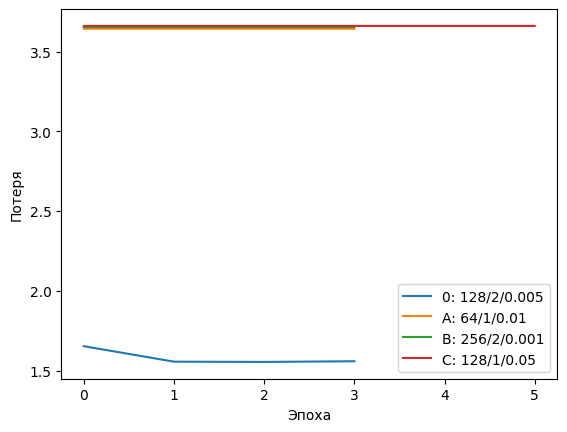

In [ ]:
plt.plot(train_losses, label='0: 128/2/0.005')
plt.plot(train_losses_A, label='A: 64/1/0.01')
plt.plot(train_losses_B, label='B: 256/2/0.001')
plt.plot(train_losses_C, label='C: 128/1/0.05')
plt.xlabel('Эпоха')
plt.ylabel('Потеря')
plt.legend()
plt.show()

Были обучены модели с разными наборами параметров:

0) модель с семинара hidden_size=128, num_layers=2, learning rate = 0.005. С такими гиперпараметрами модель обучилась наилучшим образом (Средние потери примерно 1.6). Кроме того, эта модель демонстрирует оптимальное время обучения - 6 минут. Сгенерированный текст получается не совсем осмысленным, присутствуют галлюцинации, модель генерирует несуществующие слова и отдельные символы: "the company said to reftert this year semport cash projection of t". Однако, только у этой модели получилось сгенерировать что-то хотя бы напоминающее текст.

A) модель А,  где был установлен размер скрыторого слоя (hidden_size) 128, количество  слоев (num_layers) 1, скорость обучения (learning rate) 0.01. Модель обучалась 4 минуты. В отличие от первой модели, здесь уменьшается количество слоев, но увеличивается скорость обучения, т.е. веса чаще обновляются на каждом шаге обучения. Изменение параметров привело к тому, что модель перестает обучаться: потери не уменьшаются с количеством эпох, loss колеблется в диапазоне 3.6 - 3.7; средняя ошибка - 3.6. Это не похоже на переобучение, т.к. потери не меняются вообще с самой первой эпохи обучения. Текст генерируется полностью не осмысленный: "the company said 8sfa?zhknah2q1n9ubtz89el8eyiy6?9gwv'e6j12t'x9ybx5". Не совсем понятно, почему смена гиперпараметров могла так сильно ухудшить обучение. Например, слишком маленькая скорость обучения могла потенциально привести к тому, что модель "застряет" на определенном диапазоне потерь, т.к. вектора меняются незначительно. Тогда было бы полезно проверить такую модель, увеличив количество эпох. Однако в сравнении с моделью 0, здесь более высокая скорость обучения.

B) модель B, где был установлен размер скрыторого слоя (hidden_size) 256, количество  слоев (num_layers) 2, скорость обучения (learning rate) 0.001. Модель обучалась 17 минут. Несмотря на то, что модель с такими гиперпараметрами должна быть более глубокой и сложной, она не демонстрирует улучшений в качестве генерации. Средняя ошибка - 3.7, важно, что потери также не уменьшаются с увеличением эпох, loss колеблется в том же диапазоне 3.6 - 3.7. Осмысленный текст не генерируется (в общем-то сгенерированная последовательность не похожа на текст даже внешне, в отличие от модели 0): "the company said fhrtmyzpsqelrr2e487hca8 25zllsw'dmh61gi6fmd h7d 8"

С) модель С, где был установлен размер скрыторого слоя (hidden_size) 128, количество  слоев (num_layers) 1, скорость обучения (learning rate) 0.05. Кроме того, было увеличено количество эпох до 6. Модель обучалась 6 минут. Была увеличена скорость обучения и количество эпох для проверки улучшения качества генерации модели A, если проблема заключалась все-таки в недостаточной скорости и недостаточном количестве эпох. Однако это не привело к улучшению качества генерации модели, потери все еще колеблются в диапазоне 3.6-3.7 и не уменьшаются с увеличением эпох. Текст полностью неосмысленный "the company said'5'a0dkvkop2xibmwe611sn?e4mp9w748ae'iahui2e0kp20q3".

Возможно, возникшая проблема связана не с подбором гиперпараметров, но с данными.

### **ВОПРОСЫ ДЛЯ РЕФЛЕКСИИ**

1.  Какие ключевые отличия вы заметили в подготовке данных для числового ряда (синусоида) и текста?

Ключевое отличие в том, что данные для числового ряда не требуют некоторых обязательных препроцессинговых этапов обработки текста. Так, данные числового ряда не требуют токенизации, построения словаря и эмбеддингов.

2.  Какой опыт работы с PyTorch (например, отладка, подбор параметров) оказался самым полезным?

Примеры моделей 0-С, теряющими качество обучения с малейшим изменением параметров, очень доходчиво объясняет значимость подбора параметров. Однако жаль, что решить проблемы подбором параметров из гипотезы о маленькой скорость обучения и недостаточностью эпох не вышло.